<a href="https://colab.research.google.com/github/Stormchaser5775/chess-engine/blob/main/CIFAR_Base_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Connect to a T4 (GPU) runtime in the top right.

###Download the dataset - No need! It's built into PyTorch.

###Complete the following using the an AI coding assistant and the prompts! Also remember to keep your coding assistant window open so that it remembers where it left off.
###Load the data

In [ ]:
# Install PyTorch if needed (Colab usually has it preinstalled)
# !pip install torch torchvision

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Transforms
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010),
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010),
    ),
])

# -----------------------------
# CIFAR-10 Datasets
# -----------------------------
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train,
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test,
)

# -----------------------------
# DataLoaders
# -----------------------------
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# -----------------------------
# Class names
# -----------------------------
classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# -----------------------------
# Sanity check: one batch
# -----------------------------
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)


Using device: cuda


100%|██████████| 170M/170M [00:02<00:00, 69.8MB/s]


Train samples: 50000
Test samples: 10000
Batch images shape: torch.Size([128, 3, 32, 32])
Batch labels shape: torch.Size([128])


###Create the model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Device (reuse from previous cell if already defined)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# CNN Model Definition
# -----------------------------
class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFAR10CNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 16x16 → 8x8
        x = self.pool(F.relu(self.conv3(x)))  # 8x8 → 4x4

        x = x.view(x.size(0), -1)              # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# -----------------------------
# Instantiate model
# -----------------------------
model = CIFAR10CNN(num_classes=10).to(device)

print(model)

# -----------------------------
# Sanity check with dummy input
# -----------------------------
dummy_input = torch.randn(1, 3, 32, 32).to(device)
dummy_output = model(dummy_input)
print("Output shape:", dummy_output.shape)


CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Output shape: torch.Size([1, 10])


###Train the model
Create a training script. Use the DataLoaders to train the model.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Loss and Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# Training / Evaluation Loops
# -----------------------------
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# -----------------------------
# Training Loop
# -----------------------------
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 1.6644, Train Acc: 0.3859 | Test Loss: 1.2804, Test Acc: 0.5351
Epoch [2/10] | Train Loss: 1.3071, Train Acc: 0.5284 | Test Loss: 1.0735, Test Acc: 0.6180
Epoch [3/10] | Train Loss: 1.1334, Train Acc: 0.5968 | Test Loss: 0.9850, Test Acc: 0.6518
Epoch [4/10] | Train Loss: 1.0158, Train Acc: 0.6452 | Test Loss: 0.8570, Test Acc: 0.7012
Epoch [5/10] | Train Loss: 0.9340, Train Acc: 0.6707 | Test Loss: 0.7755, Test Acc: 0.7265
Epoch [6/10] | Train Loss: 0.8807, Train Acc: 0.6933 | Test Loss: 0.7610, Test Acc: 0.7319
Epoch [7/10] | Train Loss: 0.8413, Train Acc: 0.7078 | Test Loss: 0.7507, Test Acc: 0.7346
Epoch [8/10] | Train Loss: 0.7968, Train Acc: 0.7252 | Test Loss: 0.7091, Test Acc: 0.7543
Epoch [9/10] | Train Loss: 0.7758, Train Acc: 0.7310 | Test Loss: 0.6756, Test Acc: 0.7648
Epoch [10/10] | Train Loss: 0.7481, Train Acc: 0.7398 | Test Loss: 0.6763, Test Acc: 0.7620


###Visualize the results
Create a confusion matrix to display how accurate the model is.

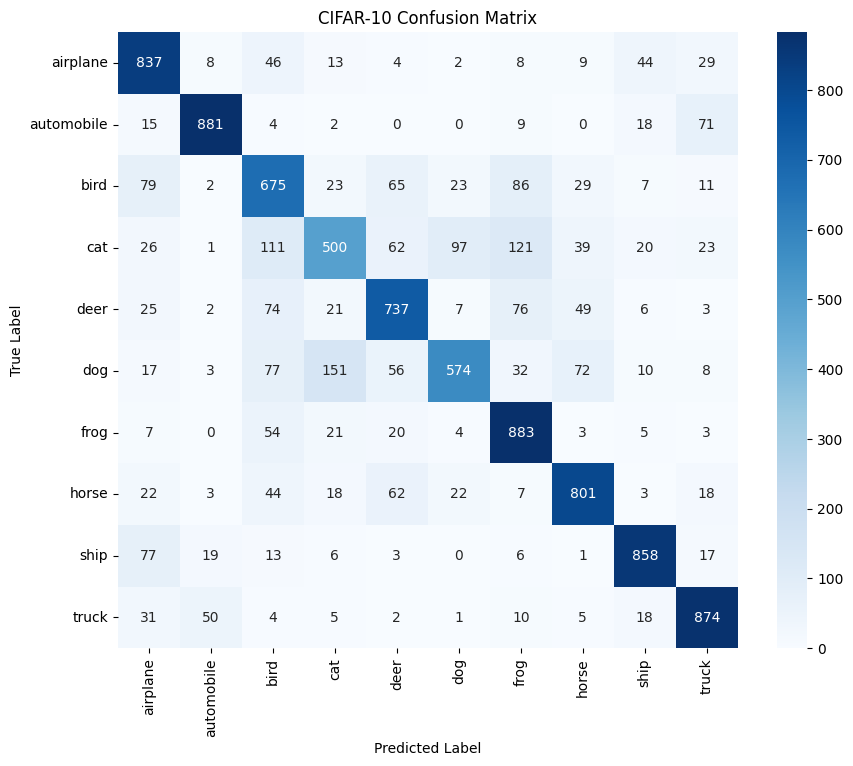

Per-class accuracy:
airplane  : 83.70%
automobile: 88.10%
bird      : 67.50%
cat       : 50.00%
deer      : 73.70%
dog       : 57.40%
frog      : 88.30%
horse     : 80.10%
ship      : 85.80%
truck     : 87.40%


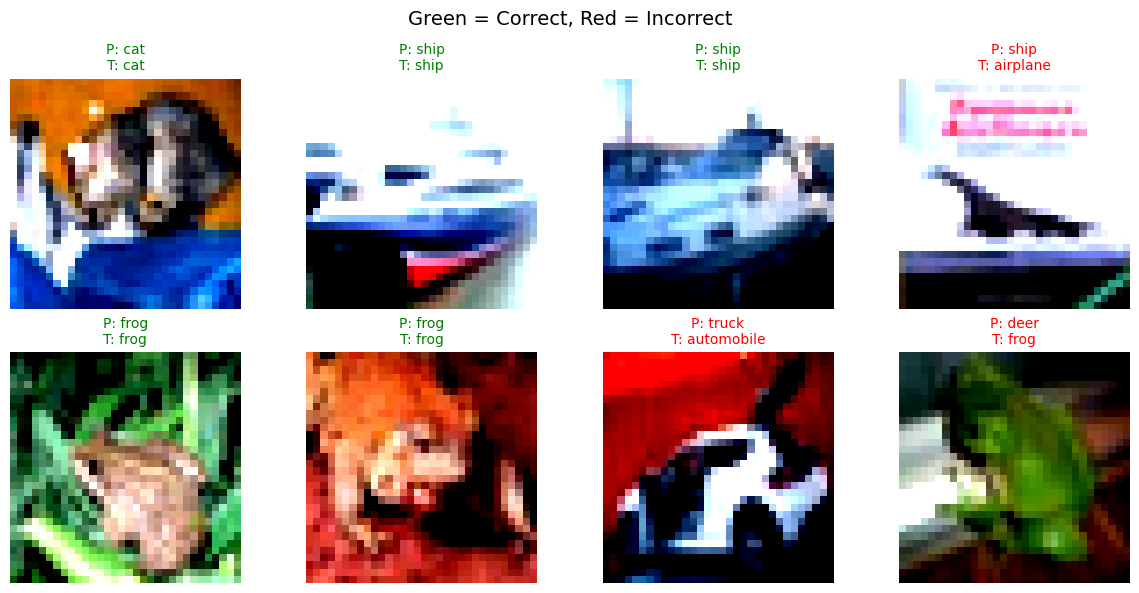

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------
# Collect predictions
# -----------------------------
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

# -----------------------------
# Per-class accuracy
# -----------------------------
class_correct = np.zeros(len(classes))
class_total = np.zeros(len(classes))

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

print("Per-class accuracy:")
for i, class_name in enumerate(classes):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{class_name:10s}: {acc:.2f}%")

# -----------------------------
# Visualize some predictions
# -----------------------------
def imshow(img):
    img = img / 2 + 0.5  # unnormalize (approx)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    color = "green" if preds[i] == labels[i] else "red"
    plt.title(
        f"P: {classes[preds[i]]}\nT: {classes[labels[i]]}",
        color=color,
        fontsize=10,
    )

plt.suptitle("Green = Correct, Red = Incorrect", fontsize=14)
plt.tight_layout()
plt.show()
